## 이전까지의 방법


In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train_scaled, y_train)
pred = lr_clf.predict(X_test_scaled)

## 파이프라인을 가져와서 실행하는 방법


In [8]:
from sklearn.pipeline import Pipeline

# 파이프라인 생성자 가져와서 모델 지정하여 생성

pipeline = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression())])

# 파이프라인 객체 내부 확인
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio)

In [5]:
# X_train_scaled는 StandardScaler에서 스케일링을 한 데이터이기 때문에
# X_train을 넣어야 함. (StandardScaler를 거치지 않은 상태)

# pipeline 학습 시에는 독립변수와 종속변수를 넣어준다.
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [6]:
pred = pipeline.predict(X_test)

In [ ]:
pipeline.named_steps["scaler"]

StandardScaler()

# SimpleImputer


In [49]:
# Impute : 누락된 값을 추정하여 채워 넣다(대체하다)
from sklearn.impute import SimpleImputer
import pandas as pd

titanic = pd.read_csv("./data/titanic.csv")

simpleImputer = SimpleImputer()
simpleImputer.fit_transform(titanic[["Age"]])

array([[22.        ],
       [38.        ],
       [26.        ],
       [35.        ],
       [35.        ],
       [29.69911765],
       [54.        ],
       [ 2.        ],
       [27.        ],
       [14.        ],
       [ 4.        ],
       [58.        ],
       [20.        ],
       [39.        ],
       [14.        ],
       [55.        ],
       [ 2.        ],
       [29.69911765],
       [31.        ],
       [29.69911765],
       [35.        ],
       [34.        ],
       [15.        ],
       [28.        ],
       [ 8.        ],
       [38.        ],
       [29.69911765],
       [19.        ],
       [29.69911765],
       [29.69911765],
       [40.        ],
       [29.69911765],
       [29.69911765],
       [66.        ],
       [28.        ],
       [42.        ],
       [29.69911765],
       [21.        ],
       [18.        ],
       [14.        ],
       [40.        ],
       [27.        ],
       [29.69911765],
       [ 3.        ],
       [19.        ],
       [29

In [11]:
import numpy as np

simpleimputer = SimpleImputer(
    missing_values=np.nan,
    strategy="constant",
    fill_value="N",
)
simpleimputer.fit_transform(titanic[["Cabin"]])

array([['N'],
       ['C85'],
       ['N'],
       ['C123'],
       ['N'],
       ['N'],
       ['E46'],
       ['N'],
       ['N'],
       ['N'],
       ['G6'],
       ['C103'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['D56'],
       ['N'],
       ['A6'],
       ['N'],
       ['N'],
       ['N'],
       ['C23 C25 C27'],
       ['N'],
       ['N'],
       ['N'],
       ['B78'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['D33'],
       ['N'],
       ['B30'],
       ['C52'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['N'],
       ['B28'],
       ['C83'],
       ['N'],
       ['N'],
       ['N'],
       ['F33'],
       ['N'],
       ['N

In [ ]:
titanic = pd.read_csv("data/titanic.csv")
X = titanic.drop(
    ["Survived", "PassengerId", "Name", "Ticket", "Cabin", "Embarked", "Sex"], axis=1
)

y = titanic["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [15]:
# 파이프라인(누락값 전처리 모델, 스케일링, 로지스틱 회귀(분류)) 한 번에 수행
pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression()),
    ]
)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)
print(f"테스트 정확도: {accuracy:.4f}")

테스트 정확도: 0.7374


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = titanic.drop(["Survived", "PassengerId", "Name", "Ticket", "Cabin"], axis=1)
y = titanic["Survived"]

cat_features = ["Embarked", "Sex"]
num_features = ["Age", "Fare"]

## Pipeline을 사용한 방법


In [ ]:
# handle_unknown='ignore'
#

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="passthrough",
)

result = preprocessor.fit_transform(X)
print(result)

[[-0.53037664 -0.50244517  0.         ...  3.          1.
   0.        ]
 [ 0.57183099  0.78684529  1.         ...  1.          1.
   0.        ]
 [-0.25482473 -0.48885426  0.         ...  3.          0.
   0.        ]
 ...
 [        nan -0.17626324  0.         ...  3.          1.
   2.        ]
 [-0.25482473 -0.04438104  1.         ...  1.          0.
   0.        ]
 [ 0.15850313 -0.49237783  0.         ...  3.          0.
   0.        ]]


## Pipeline을 사용하지 않은 방법


In [ ]:
scaler = StandardScaler()
num_X = scaler.fit_transform(X[num_features])
num_df = pd.DataFrame(num_X, columns=num_features)

oh_enc = OneHotEncoder(sparse_output=False)
cat_X = oh_enc.fit_transform(X[cat_features])
cat_df = pd.DataFrame(cat_X, columns=oh_enc.get_feature_names_out())

remain_features = ["Pclass", "SibSp", "Parch"]
remain_X = X[remain_features]

X_tr = pd.concat([num_df, cat_df, remain_X], axis=1)

print(X_tr)

          Age      Fare  Embarked_C  Embarked_Q  Embarked_S  Embarked_nan  \
0   -0.530377 -0.502445         0.0         0.0         1.0           0.0   
1    0.571831  0.786845         1.0         0.0         0.0           0.0   
2   -0.254825 -0.488854         0.0         0.0         1.0           0.0   
3    0.365167  0.420730         0.0         0.0         1.0           0.0   
4    0.365167 -0.486337         0.0         0.0         1.0           0.0   
..        ...       ...         ...         ...         ...           ...   
886 -0.185937 -0.386671         0.0         0.0         1.0           0.0   
887 -0.737041 -0.044381         0.0         0.0         1.0           0.0   
888       NaN -0.176263         0.0         0.0         1.0           0.0   
889 -0.254825 -0.044381         1.0         0.0         0.0           0.0   
890  0.158503 -0.492378         0.0         1.0         0.0           0.0   

     Sex_female  Sex_male  Pclass  SibSp  Parch  
0           0.0       1.0

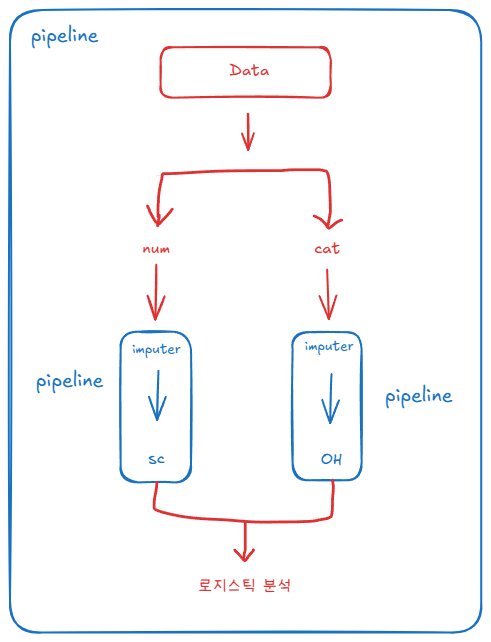


In [ ]:
# pipeline 3개
# pipe(imputer_mean -> scaler) : num_pipe
# pipe(imputer_most(_frequent) -> oh_enc) : cat_pipe
# ColumnTransformer(num_pipe, cat_pipe)
# pipe(ColumnTransformer -> LogisticRegression)

In [ ]:
num_features = ["Age", "Fare", "SibSp", "Parch"]
cat_features = ["Embarked", "Sex", "Pclass"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

num_pipe = Pipeline([("imputer_mean", SimpleImputer()), ("scaler", StandardScaler())])

cat_pipe = Pipeline(
    [
        ("imputer_most", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

CT = ColumnTransformer(
    [("num", num_pipe, num_features), ("cat", cat_pipe, cat_features)],
    remainder="passthrough",
)

pipe = Pipeline([("CT", CT), ("LR", LogisticRegression())])

In [35]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('CT', ...), ('LR', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,num,Pipeline(step...ardScaler())])
,cat,Pipeline(step...n='ignore'

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.8044692737430168

## 생성한 pipeline을 GridSearchCV에 넣어보자


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error

diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
pipe = Pipeline(
    [("scaler", StandardScaler()), ("poly", PolynomialFeatures()), ("model", Ridge())]
)

In [ ]:
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.4525688819189262

In [44]:
# GridSearchCV의 파라미터들
param_grid = [
    {
        "scaler": [StandardScaler(), MinMaxScaler()],
        "poly": [PolynomialFeatures(degree=2)],
        "poly__degree": [2, 3],
        "model": [Ridge(), Lasso()],
        "model__alpha": [0.01, 0.001],
    },
    {
        "scaler": [StandardScaler(), MinMaxScaler()],
        "poly": [None],
        "model": [LinearRegression()],
    },
]

In [47]:
# 하이퍼파라미터 튜닝
# verbose : 진행상황을 보여주는 속성
# 경우의 수가 18개인 이유 : 위 16개 + 아래 2개
# 총 5번 교차검증 -> 90번 학습

grid_search = GridSearchCV(
    pipe, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1, verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [Ridge(), Lasso()], 'model__alpha': [0.01, 0.001], 'poly': [PolynomialFeatures()], 'poly__degree': [2, 3], ...}, {'model': [LinearRegression()], 'poly': [None], 'scaler': [StandardScaler(), MinMaxScaler()]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this

In [48]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__alpha,param_poly,param_poly__degree,param_scaler,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004643,0.000686,0.001590,0.000195,Ridge(),0.010,PolynomialFeatures(),2.0,StandardScaler(),"{'model': Ridge(), 'model__alpha': 0.01, 'poly...",-3369.301498,-4845.755820,-3988.058541,-4381.777392,-3566.847165,-4030.348083,537.028199,10
1,0.004565,0.000194,0.001810,0.000163,Ridge(),0.010,PolynomialFeatures(),2.0,MinMaxScaler(),"{'model': Ridge(), 'model__alpha': 0.01, 'poly...",-3246.943721,-4611.316159,-2832.066627,-3954.825544,-3307.948018,-3590.620014,624.161258,4
2,0.009727,0.001644,0.002758,0.000693,Ridge(),0.010,PolynomialFeatures(),3.0,StandardScaler(),"{'model': Ridge(), 'model__alpha': 0.01, 'poly...",-56446.980744,-125079.307123,-65240.380741,-139369.417464,-76662.686461,-92559.754507,33322.254524,17
3,0.011657,0.001245,0.003140,0.000193,Ridge(),0.010,PolynomialFeatures(),3.0,MinMaxScaler(),"{'model': Ridge(), 'model__alpha': 0.01, 'poly...",-4106.887992,-7006.077725,-3725.815798,-6608.564568,-4229.164894,-5135.302195,1380.990629,12
4,0.007392,0.000940,0.002573,0.000141,Ridge(),0.001,PolynomialFeatures(),2.0,StandardScaler(),"{'model': Ridge(), 'model__alpha': 0.001, 'pol...",-3373.656969,-4930.010808,-3915.957310,-4373.457651,-3550.639487,-4028.744445,565.959917,9
5,0.004933,0.000863,0.001788,0.000310,Ridge(),0.001,PolynomialFeatures(),2.0,MinMaxScaler(),"{'model': Ridge(), 'model__alpha': 0.001, 'pol...",-3313.100719,-4770.557877,-3224.122756,-4228.696876,-3382.206384,-3783.736922,611.178890,6
6,0.012292,0.000697,0.003040,0.000276,Ridge(),0.001,PolynomialFeatures(),3.0,StandardScaler(),"{'model': Ridge(), 'model__alpha': 0.001, 'pol...",-78864.035494,-384749.838448,-94927.952275,-206140.925948,-155443.348997,-184025.220233,110085.056291,18
7,0.012392,0.000916,0.002825,0.000527,Ridge(),0.001,PolynomialFeatures(),3.0,MinMaxScaler(),"{'model': Ridge(), 'model__alpha': 0.001, 'pol...",-6673.348652,-11787.353275,-5060.484640,-10210.638942,-7359.874621,-8218.340026,2441.439017,14
8,0.020152,0.002329,0.002529,0.000553,Lasso(),0.010,PolynomialFeatures(),2.0,StandardScaler(),"{'model': Lasso(), 'model__alpha': 0.01, 'poly...",-3356.407686,-4811.868248,-3690.178994,-4366.013814,-3571.979872,-3959.289723,543.729875,7
9,0.016749,0.002765,0.002357,0.000357,Lasso(),0.010,PolynomialFeatures(),2.0,MinMaxScaler(),"{'model': Lasso(), 'model__alpha': 0.01, 'poly...",-3220.963815,-4452.750873,-2792.803468,-3940.522405,-3294.545499,-3540.317212,585.468446,3


In [52]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    {
        "scaler": [StandardScaler(), MinMaxScaler()],
        "poly": [PolynomialFeatures(degree=2)],
        "poly__degree": [2, 3],
        "model": [Ridge(), Lasso()],
        "model__alpha": [0.01, 0.001],
    },
    {
        "scaler": [StandardScaler(), MinMaxScaler()],
        "poly": [None],
        "model": [LinearRegression()],
    },
    {
        "scaler": [None],
        "poly": [None],
        "model": [DecisionTreeRegressor(), RandomForestRegressor()],
        "model__max_depth": [None, 3, 5, 7],
    },
]